# Lab 9.3: Machine Learning
Covers: linear regression, feature engineering, classification, clustering, and sentiment analysis.

## 1. Linear Regression (sklearn)

Slope (w): 3.07, Intercept (b): 14.09


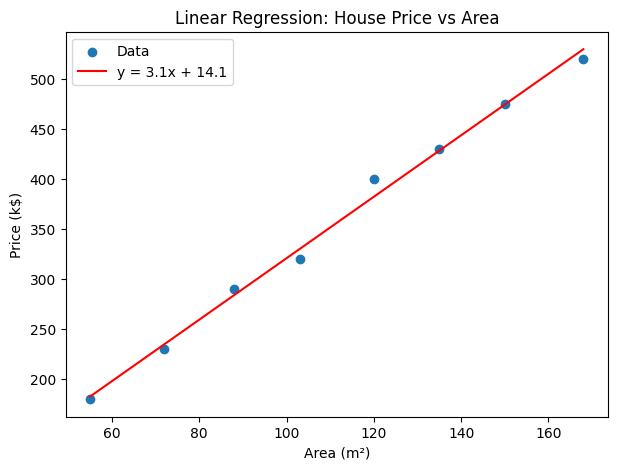

Predicted price for 100 m²: 320.7k$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# House price dataset
area = np.array([55, 72, 88, 103, 120, 135, 150, 168]).reshape(-1, 1)
price = np.array([180, 230, 290, 320, 400, 430, 475, 520])

lr = LinearRegression().fit(area, price)
w, b = lr.coef_[0], lr.intercept_
print(f"Slope (w): {w:.2f}, Intercept (b): {b:.2f}")

plt.figure(figsize=(7, 5))
plt.scatter(area, price, label="Data")
plt.plot(area, lr.predict(area), color="red", label=f"y = {w:.1f}x + {b:.1f}")
plt.xlabel("Area (m²)")
plt.ylabel("Price (k$)")
plt.title("Linear Regression: House Price vs Area")
plt.legend()
plt.savefig("../output/9_3_1_linear_regression.png", dpi=100, bbox_inches="tight")
plt.show()

test_area = np.array([[100]])
print(f"Predicted price for 100 m²: {lr.predict(test_area)[0]:.1f}k$")

## 2. Linear Regression from Scratch (Gradient Descent)

Epoch     0 | Loss: 4269.9000 | w=0.0000 b=0.0000
Epoch  2000 | Loss: 4.7936 | w=1.0478 b=0.3259
Epoch  4000 | Loss: 4.3862 | w=1.0437 b=0.6112
Epoch  6000 | Loss: 4.0430 | w=1.0400 b=0.8731


Epoch  8000 | Loss: 3.7538 | w=1.0366 b=1.1135
Epoch 10000 | Loss: 3.5102 | w=1.0334 b=1.3341


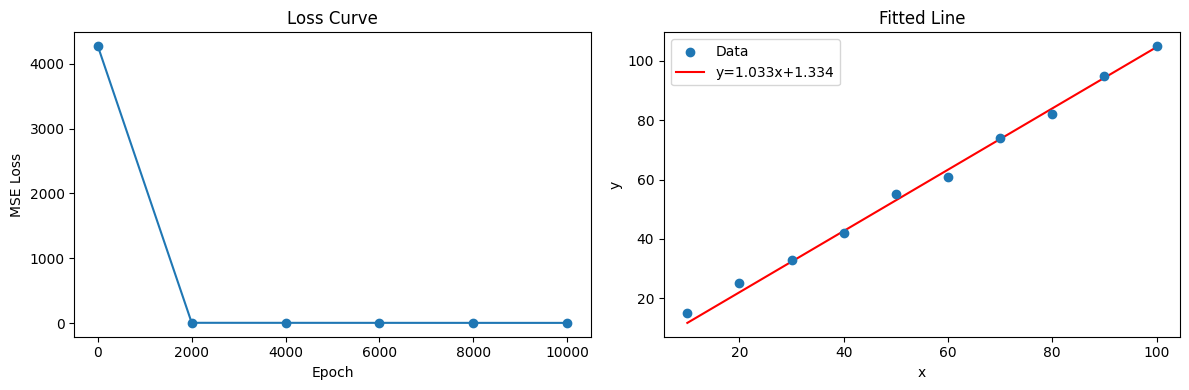

In [2]:
x_data = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100], dtype=float)
y_data = np.array([15, 25, 33, 42, 55, 61, 74, 82, 95, 105], dtype=float)


def model(w, b, x):
    return w * x + b


def mse_loss(w, b, x, y):
    return np.mean((model(w, b, x) - y) ** 2)


def gradient_step(w, b, x, y, lr):
    n = len(x)
    pred = model(w, b, x)
    dw = (2 / n) * np.sum((pred - y) * x)
    db = (2 / n) * np.sum(pred - y)
    return w - lr * dw, b - lr * db


w, b, learning_rate = 0.0, 0.0, 0.0001
losses = []
for epoch in range(10000):
    loss = mse_loss(w, b, x_data, y_data)
    if epoch % 2000 == 0:
        losses.append((epoch, loss))
        print(f"Epoch {epoch:5d} | Loss: {loss:.4f} | w={w:.4f} b={b:.4f}")
    w, b = gradient_step(w, b, x_data, y_data, learning_rate)

loss = mse_loss(w, b, x_data, y_data)
losses.append((10000, loss))
print(f"Epoch 10000 | Loss: {loss:.4f} | w={w:.4f} b={b:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot([l[0] for l in losses], [l[1] for l in losses], marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Loss Curve")

axes[1].scatter(x_data, y_data, label="Data", zorder=5)
axes[1].plot(x_data, model(w, b, x_data), color="red", label=f"y={w:.3f}x+{b:.3f}")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_title("Fitted Line")
axes[1].legend()
plt.tight_layout()
plt.savefig("../output/9_3_2_gradient_descent.png", dpi=100, bbox_inches="tight")
plt.show()

## 3. Feature Engineering (Bank Credit Data)

In [3]:
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import chi2, RFE, SelectKBest
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PolynomialFeatures

# Synthetic bank credit dataset
np.random.seed(42)
n = 200
df_bank = pd.DataFrame({
    "Age": np.random.randint(22, 65, n),
    "Income": np.random.normal(60000, 20000, n).astype(int),
    "LoanAmount": np.random.normal(15000, 7000, n).round(2),
    "CreditScore": np.random.randint(300, 850, n),
    "Duration": np.random.choice([12, 24, 36, 48, 60], n),
    "Default": np.random.choice([0, 1], p=[0.85, 0.15], size=n),
})

# Inject some NaNs
df_bank.loc[np.random.choice(n, 15, replace=False), "Age"] = np.nan
df_bank.loc[np.random.choice(n, 20, replace=False), "LoanAmount"] = np.nan

print("Missing values:\n", df_bank.isnull().sum())

# Fill missing values
for col in ["Age", "LoanAmount"]:
    df_bank[col] = df_bank[col].fillna(df_bank[col].median())

print("\nAfter imputation:\n", df_bank.isnull().sum())

Missing values:
 Age            15
Income          0
LoanAmount     20
CreditScore     0
Duration        0
Default         0
dtype: int64

After imputation:
 Age            0
Income         0
LoanAmount     0
CreditScore    0
Duration       0
Default        0
dtype: int64


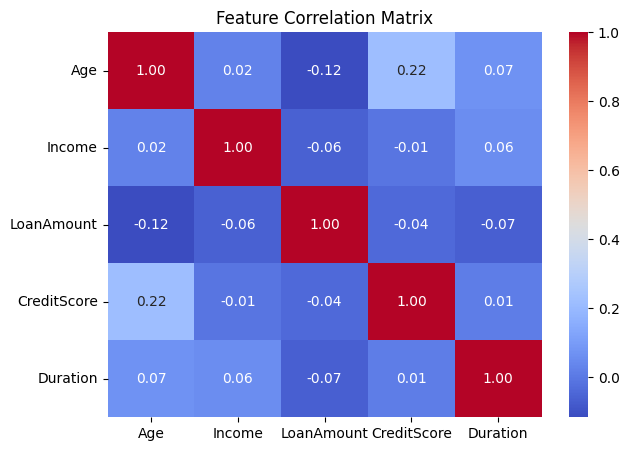

In [4]:
# Correlation heatmap
corr = df_bank.drop(columns=["Default"]).corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.savefig("../output/9_3_3_correlation.png", dpi=100, bbox_inches="tight")
plt.show()

Feature importances:
 Duration       0.104683
Age            0.179597
LoanAmount     0.232209
CreditScore    0.233026
Income         0.250484
dtype: float64


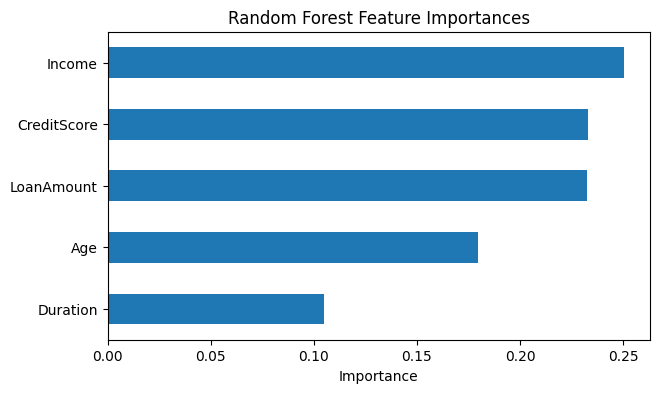

In [5]:
# Feature importance with Random Forest
X_bank = df_bank.drop(columns=["Default"])
y_bank = df_bank["Default"]

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_bank, y_bank)

importances = pd.Series(rf.feature_importances_, index=X_bank.columns).sort_values(ascending=True)
print("Feature importances:\n", importances)

importances.plot.barh(figsize=(7, 4))
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.savefig("../output/9_3_3_feature_importance.png", dpi=100, bbox_inches="tight")
plt.show()

## 4. Classification: Titanic Survival Prediction

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score

titanic = sns.load_dataset("titanic")
print("Shape:", titanic.shape)
print(titanic.head())

Shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [7]:
# Preprocessing
titanic["age"] = titanic["age"].fillna(titanic["age"].median())
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])
titanic["sex"] = titanic["sex"].map({"male": 0, "female": 1})
titanic["embarked"] = titanic["embarked"].map({"S": 0, "C": 1, "Q": 2})

features = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]
X_t = titanic[features].fillna(0)
y_t = titanic["survived"]

X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

In [8]:
# Train multiple classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train, y_train)
    acc = accuracy_score(y_test, mdl.predict(X_test))
    results[name] = acc
    print(f"{name}: {acc:.4f}")

# Survival rate by class
print("\nSurvival by class:")
print(titanic.groupby("pclass")["survived"].mean())

Logistic Regression: 0.7989
Random Forest: 0.8268
AdaBoost: 0.7933

Survival by class:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


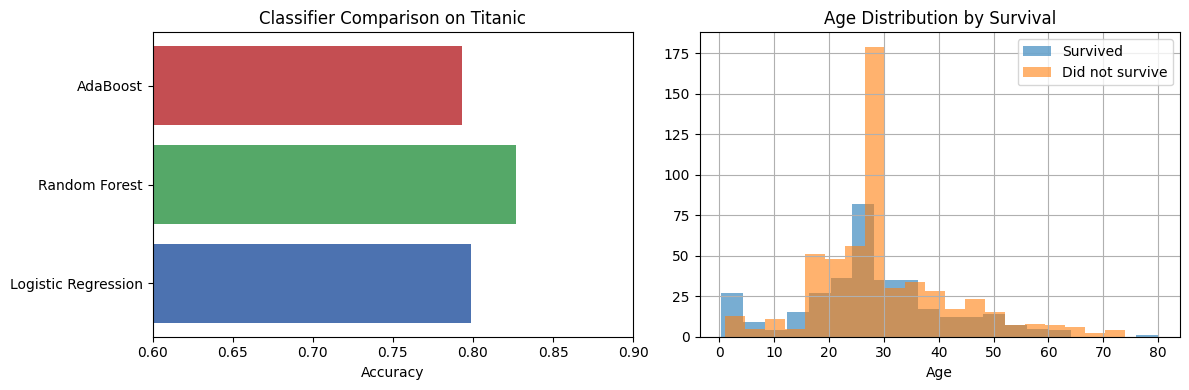

In [9]:
# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Model comparison
axes[0].barh(list(results.keys()), list(results.values()), color=["#4C72B0", "#55A868", "#C44E52"])
axes[0].set_xlabel("Accuracy")
axes[0].set_title("Classifier Comparison on Titanic")
axes[0].set_xlim(0.6, 0.9)

# Age distribution by survival
titanic[titanic["survived"] == 1]["age"].hist(ax=axes[1], alpha=0.6, bins=20, label="Survived")
titanic[titanic["survived"] == 0]["age"].hist(ax=axes[1], alpha=0.6, bins=20, label="Did not survive")
axes[1].set_xlabel("Age")
axes[1].set_title("Age Distribution by Survival")
axes[1].legend()

plt.tight_layout()
plt.savefig("../output/9_3_4_titanic.png", dpi=100, bbox_inches="tight")
plt.show()

## 5. Iris Classification (Multiple Models)

In [10]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_i, y_i = iris.data, iris.target
X_tr, X_te, y_tr, y_te = train_test_split(X_i, y_i, test_size=0.25, random_state=42)

print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
}

for name, clf in classifiers.items():
    clf.fit(X_tr, y_tr)
    print(f"{name}: {accuracy_score(y_te, clf.predict(X_te)):.4f}")

# After scaling
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

svm_scaled = SVC()
svm_scaled.fit(X_tr_s, y_tr)
print(f"\nSVM after scaling: {accuracy_score(y_te, svm_scaled.predict(X_te_s)):.4f}")

Train: (112, 4), Test: (38, 4)
Logistic Regression: 1.0000
SVM: 1.0000
Decision Tree: 1.0000
KNN (k=5): 1.0000

SVM after scaling: 1.0000


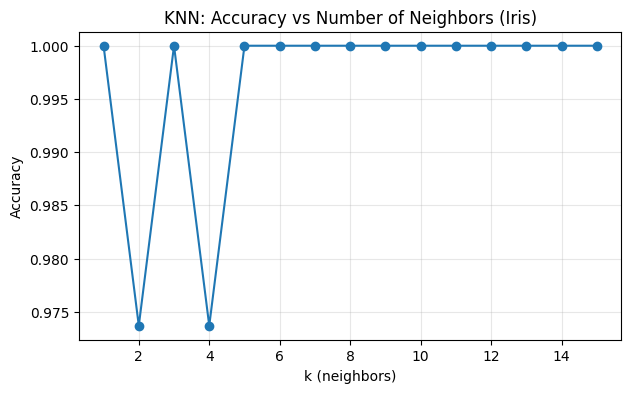

In [11]:
# KNN accuracy vs k
k_range = range(1, 16)
k_acc = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_tr_s, y_tr)
    k_acc.append(accuracy_score(y_te, knn.predict(X_te_s)))

plt.figure(figsize=(7, 4))
plt.plot(k_range, k_acc, marker="o")
plt.xlabel("k (neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN: Accuracy vs Number of Neighbors (Iris)")
plt.grid(True, alpha=0.3)
plt.savefig("../output/9_3_5_knn_iris.png", dpi=100, bbox_inches="tight")
plt.show()

## 6. K-Means Clustering

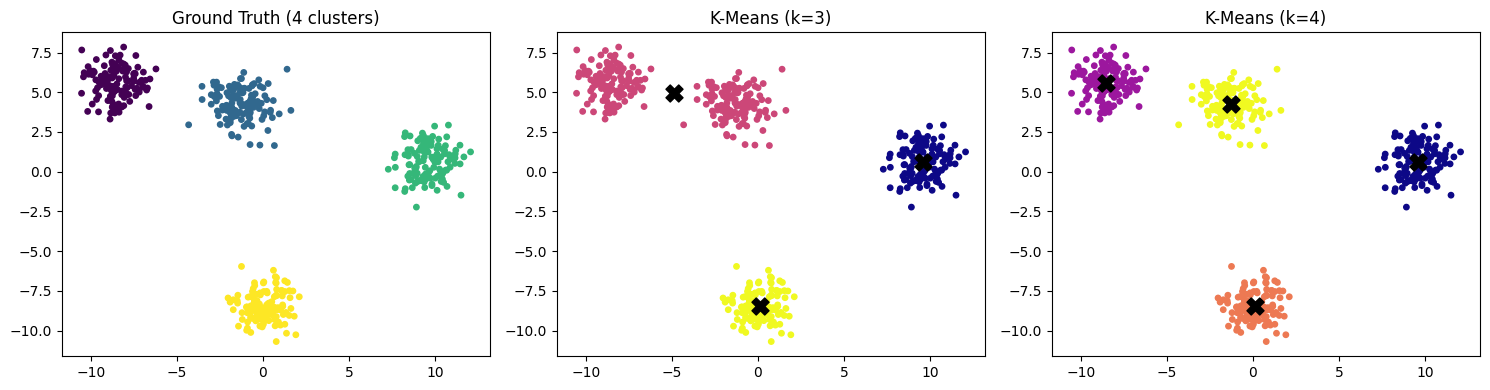

In [12]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X_blob, y_blob = make_blobs(n_samples=500, n_features=2, centers=4, random_state=7)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Ground truth
axes[0].scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap="viridis", s=15)
axes[0].set_title("Ground Truth (4 clusters)")

# K=3
km3 = KMeans(n_clusters=3, random_state=0).fit(X_blob)
axes[1].scatter(X_blob[:, 0], X_blob[:, 1], c=km3.labels_, cmap="plasma", s=15)
axes[1].scatter(*km3.cluster_centers_.T, marker="X", s=150, c="black")
axes[1].set_title("K-Means (k=3)")

# K=4
km4 = KMeans(n_clusters=4, random_state=0).fit(X_blob)
axes[2].scatter(X_blob[:, 0], X_blob[:, 1], c=km4.labels_, cmap="plasma", s=15)
axes[2].scatter(*km4.cluster_centers_.T, marker="X", s=150, c="black")
axes[2].set_title("K-Means (k=4)")

plt.tight_layout()
plt.savefig("../output/9_3_6_kmeans.png", dpi=100, bbox_inches="tight")
plt.show()

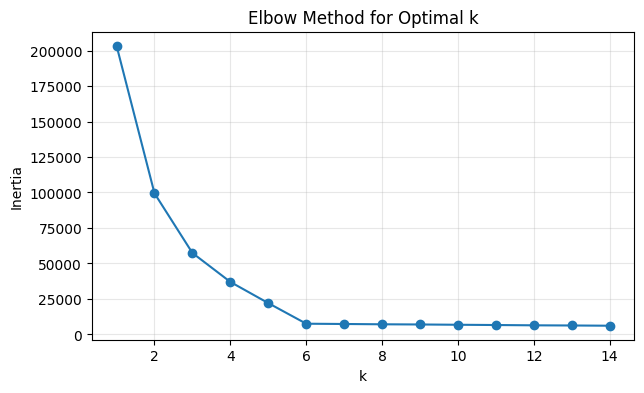

In [13]:
# Elbow method
X_elbow, _ = make_blobs(n_samples=1500, centers=6, n_features=5, random_state=42)
inertias = []
K = range(1, 15)
for k in K:
    inertias.append(KMeans(n_clusters=k, random_state=42).fit(X_elbow).inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.grid(True, alpha=0.3)
plt.savefig("../output/9_3_6_elbow.png", dpi=100, bbox_inches="tight")
plt.show()

## 7. Sentiment Analysis (NLP with TF-IDF)

In [14]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

reviews = pd.DataFrame({
    "text": [
        "terrible product broke after one day",
        "amazing quality would buy again",
        "cheap and flimsy not worth the money",
        "love it perfect for everyday use",
        "worst purchase ever do not recommend",
        "excellent value great performance",
        "disappointing poor build quality",
        "fantastic item exceeded expectations",
        "returned immediately very bad",
        "superb works exactly as described",
        "waste of money fell apart quickly",
        "highly recommend five stars",
        "garbage product useless",
        "best purchase this year love it",
        "never buying this brand again awful",
        "outstanding quality premium feel",
    ],
    "sentiment": ["neg", "pos", "neg", "pos", "neg", "pos", "neg", "pos",
                   "neg", "pos", "neg", "pos", "neg", "pos", "neg", "pos"],
})

X_train_nlp, X_test_nlp, y_train_nlp, y_test_nlp = train_test_split(
    reviews["text"], reviews["sentiment"], test_size=0.25, random_state=42
)

pipeline = Pipeline([
    ("vect", CountVectorizer()),
    ("tfidf", TfidfTransformer()),
    ("clf", MultinomialNB()),
])
pipeline.fit(X_train_nlp, y_train_nlp)
print(f"Sentiment classifier accuracy: {pipeline.score(X_test_nlp, y_test_nlp):.2f}")

# Predict on new text
new_texts = ["great product really enjoyed it", "bad quality never again"]
predictions = pipeline.predict(new_texts)
for text, pred in zip(new_texts, predictions):
    print(f"  '{text}' -> {pred}")

Sentiment classifier accuracy: 0.50
  'great product really enjoyed it' -> pos
  'bad quality never again' -> neg
